<a href="https://colab.research.google.com/github/k2herat/DL2/blob/hw5/Almetov_HW5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!git clone https://github.com/ByteDance-Seed/Depth-Anything-3.git
!pip install torch torchvision pillow matplotlib urllib3 scikit-learn

Cloning into 'Depth-Anything-3'...
remote: Enumerating objects: 359, done.
remote: Counting objects: 100% (2/2), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 359 (delta 0), reused 0 (delta 0), pack-reused 357 (from 2)
Receiving objects: 100% (359/359), 22.66 MiB | 18.70 MiB/s, done.
Resolving deltas: 100% (154/154), done.


In [ ]:
# Вместо простого sys.path.append, лучше сделать так:
!pip install -e Depth-Anything-3

# После этого перезагрузи ядро (Restart Kernel) в меню Jupyter
# И попробуй импорт снова:
from depth_anything_3.api import DepthAnything3

Obtaining file:///content/Depth-Anything-3
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Installing backend dependencies ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 4.5 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of opencv-python to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of plyfile to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 101.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 450.7/450.7 kB 42.2 MB/s eta 0:00:00
   ━━━━━━━━

ModuleNotFoundError: No module named 'depth_anything_3'

In [ ]:
import sys
import zipfile
import urllib.request
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics import accuracy_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# Добавляем путь к склонированному репозиторию
sys.path.append('Depth-Anything-3')
from depth_anything_3.api import DepthAnything3

# Базовые константы
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
TARGET_RES = (128, 128)
BATCH_SZ = 8
NUM_EPOCHS = 15

print(f"Вычисления будут производиться на: {DEVICE}")

/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:294: SyntaxWarning: invalid escape sequence '\d'
  lines_video = [l for l in lines if ' Video: ' in l and re.search('\d+x\d+', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:367: SyntaxWarning: invalid escape sequence '\d'
  rotation_lines = [l for l in lines if 'rotate          :' in l and re.search('\d+$', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:370: SyntaxWarning: invalid escape sequence '\d'
  match = re.search('\d+$', rotation_line)
  if event.key is 'enter':



[WARN ] Dependency `gsplat` is required for rendering 3DGS. Install via: pip install git+https://github.com/nerfstudio-project/gsplat.git@0b4dddf04cb687367602c01196913cde6a743d70
Вычисления будут производиться на: cuda


In [ ]:
dataset_link = "https://download.pytorch.org/tutorial/hymenoptera_data.zip"
archive_name = "hymenoptera_data.zip"
base_folder = Path("hymenoptera_data")

# Скачивание и распаковка
if not base_folder.exists():
    urllib.request.urlretrieve(dataset_link, archive_name)
    with zipfile.ZipFile(archive_name, 'r') as archive:
        archive.extractall(".")

def fetch_images(directory, limit=50):
    """Считывает изображения из указанной директории с помощью PIL"""
    img_list = []
    # Ищем все файлы .jpg
    file_paths = list(Path(directory).glob("*.jpg"))[:limit]

    for file_path in file_paths:
        try:
            with Image.open(file_path) as img:
                # Конвертируем в RGB и меняем размер
                img_resized = img.convert('RGB').resize(TARGET_RES)
                img_list.append(np.array(img_resized))
        except Exception as e:
            continue
    return img_list

# Загружаем выборки
train_ants_data = fetch_images(base_folder / "train" / "ants", 200)
train_bees_data = fetch_images(base_folder / "train" / "bees", 200)
val_ants_data = fetch_images(base_folder / "val" / "ants", 50)
val_bees_data = fetch_images(base_folder / "val" / "bees", 50)

# Объединяем списки и создаем метки (0 - муравьи, 1 - пчелы)
x_train_rgb = train_ants_data + train_bees_data
y_train = [0] * len(train_ants_data) + [1] * len(train_bees_data)

x_val_rgb = val_ants_data + val_bees_data
y_val = [0] * len(val_ants_data) + [1] * len(val_bees_data)

print(f"Размер обучающей выборки: {len(x_train_rgb)}")
print(f"Размер валидационной выборки: {len(x_val_rgb)}")

Размер обучающей выборки: 243
Размер валидационной выборки: 100


In [ ]:
# Инициализация модели DA3
depth_estimator = DepthAnything3(model_name="da3-small").to(DEVICE).eval()

def extract_depth_maps(image_array_list):
    """Генерирует карты глубины для списка RGB изображений"""
    depth_maps = []

    with torch.no_grad():
        for img in image_array_list:
            # Инференс модели
            prediction = depth_estimator.inference(image=[img])
            d_map = prediction.depth[0]

            if isinstance(d_map, torch.Tensor):
                d_map = d_map.cpu().numpy()

            # Min-max нормализация с защитой от деления на ноль
            d_min, d_max = d_map.min(), d_map.max()
            normalized_d = (d_map - d_min) / (d_max - d_min + 1e-7)

            # Ресайз через PIL
            d_pil = Image.fromarray(normalized_d)
            d_resized = d_pil.resize(TARGET_RES, resample=Image.BILINEAR)

            depth_maps.append(np.array(d_resized))

    return depth_maps

print("Обработка тренировочного сета...")
x_train_depth = extract_depth_maps(x_train_rgb)

print("Обработка валидационного сета...")
x_val_depth = extract_depth_maps(x_val_rgb)

# Очистка памяти
del depth_estimator
torch.cuda.empty_cache()

[INFO ] using MLP layer as FFN
Обработка тренировочного сета...
[INFO ] Processed Images Done taking 0.051764726638793945 seconds. Shape:  torch.Size([1, 3, 504, 504])
[INFO ] Model Forward Pass Done. Time: 1.7976083755493164 seconds
[INFO ] Conversion to Prediction Done. Time: 0.0029036998748779297 seconds
[INFO ] Processed Images Done taking 0.012010574340820312 seconds. Shape:  torch.Size([1, 3, 504, 504])
[INFO ] Model Forward Pass Done. Time: 0.4022703170776367 seconds
[INFO ] Conversion to Prediction Done. Time: 0.0009903907775878906 seconds
[INFO ] Processed Images Done taking 0.010965585708618164 seconds. Shape:  torch.Size([1, 3, 504, 504])
[INFO ] Model Forward Pass Done. Time: 0.10732388496398926 seconds
[INFO ] Conversion to Prediction Done. Time: 0.0008571147918701172 seconds
[INFO ] Processed Images Done taking 0.007818937301635742 seconds. Shape:  torch.Size([1, 3, 504, 504])
[INFO ] Model Forward Pass Done. Time: 0.1071317195892334 seconds
[INFO ] Conversion to Predicti

In [ ]:
class HymenopteraDepthDataset(Dataset):
    def __init__(self, images, depths, labels):
        self.images = images
        self.depths = depths
        self.labels = labels

        # Базовые трансформации
        self.to_tensor = transforms.ToTensor()
        self.normalize = transforms.Normalize(mean=[0.5], std=[0.5])

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        # Обработка RGB
        rgb_tensor = self.to_tensor(self.images[index])

        # Обработка глубины (добавляем измерение канала)
        depth_array = self.depths[index].astype(np.float32)
        depth_tensor = torch.from_numpy(depth_array).unsqueeze(0)

        # Таргет
        label_tensor = torch.tensor(self.labels[index], dtype=torch.long)

        return rgb_tensor, depth_tensor, label_tensor

# Инициализация лоадеров
train_dl = DataLoader(
    HymenopteraDepthDataset(x_train_rgb, x_train_depth, y_train),
    batch_size=BATCH_SZ,
    shuffle=True
)

val_dl = DataLoader(
    HymenopteraDepthDataset(x_val_rgb, x_val_depth, y_val),
    batch_size=BATCH_SZ,
    shuffle=False
)

In [ ]:
class FusionCNN(nn.Module):
    def __init__(self, input_channels):
        super(FusionCNN, self).__init__()

        # Блок извлечения признаков
        self.features = nn.Sequential(
            nn.Conv2d(input_channels, 16, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # Вычисление размера тензора после пулингов (128 -> 64 -> 32 -> 16)
        spatial_size = (TARGET_RES[0] // 8) * (TARGET_RES[1] // 8)
        flattened_size = 64 * spatial_size

        # Классификатор
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flattened_size, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [ ]:
def run_experiment(model, exp_name, input_type):
    """
    input_type: 'rgb', 'depth' или 'rgb+d'
    """
    model = model.to(DEVICE)
    loss_fn = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    # Фаза обучения
    for epoch in range(NUM_EPOCHS):
        model.train()
        for batch_rgb, batch_depth, batch_labels in train_dl:
            batch_labels = batch_labels.to(DEVICE)

            # Формирование входного тензора в зависимости от эксперимента
            if input_type == 'rgb':
                inputs = batch_rgb.to(DEVICE)
            elif input_type == 'depth':
                inputs = batch_depth.to(DEVICE)
            elif input_type == 'rgb+d':
                # Конкатенация RGB (3 канала) и Depth (1 канал) = 4 канала
                inputs = torch.cat((batch_rgb, batch_depth), dim=1).to(DEVICE)

            optimizer.zero_grad()
            predictions = model(inputs)
            loss = loss_fn(predictions, batch_labels)
            loss.backward()
            optimizer.step()

    # Фаза оценки
    model.eval()
    true_labels = []
    pred_labels = []

    with torch.no_grad():
        for batch_rgb, batch_depth, batch_labels in val_dl:
            if input_type == 'rgb':
                inputs = batch_rgb.to(DEVICE)
            elif input_type == 'depth':
                inputs = batch_depth.to(DEVICE)
            elif input_type == 'rgb+d':
                inputs = torch.cat((batch_rgb, batch_depth), dim=1).to(DEVICE)

            outputs = model(inputs)
            preds = torch.argmax(outputs, dim=1)

            true_labels.extend(batch_labels.numpy())
            pred_labels.extend(preds.cpu().numpy())

    final_accuracy = accuracy_score(true_labels, pred_labels)
    print(f"[{exp_name}] Итоговая точность: {final_accuracy * 100:.1f}%")

    return final_accuracy

[RGB Only] Итоговая точность: 74.0%
[Depth Only] Итоговая точность: 64.0%
[RGB-D Fusion] Итоговая точность: 75.0%


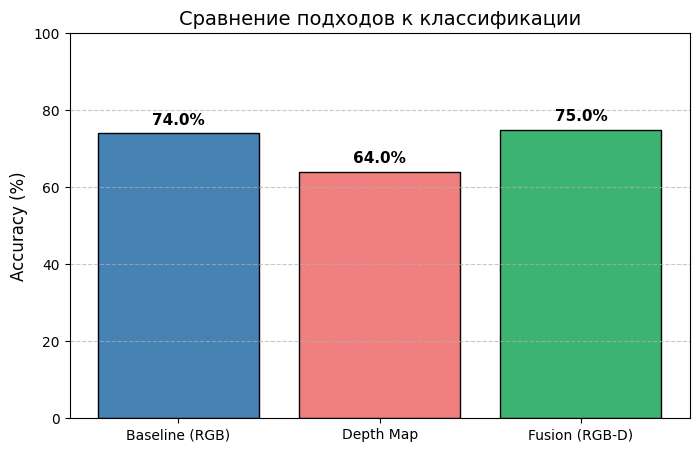

In [ ]:
# Эксперимент 1: Только цветные изображения (3 канала)
acc_rgb_only = run_experiment(FusionCNN(input_channels=3), "RGB Only", "rgb")

# Эксперимент 2: Только карта глубины (1 канал)
acc_depth_only = run_experiment(FusionCNN(input_channels=1), "Depth Only", "depth")

# Эксперимент 3: Конкатенация признаков (4 канала)
acc_fusion = run_experiment(FusionCNN(input_channels=4), "RGB-D Fusion", "rgb+d")

# Визуализация результатов
labels = ['Baseline (RGB)', 'Depth Map', 'Fusion (RGB-D)']
accuracies = [acc_rgb_only * 100, acc_depth_only * 100, acc_fusion * 100]
colors = ['steelblue', 'lightcoral', 'mediumseagreen']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, accuracies, color=colors, edgecolor='black')

ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Сравнение подходов к классификации', fontsize=14)
ax.set_ylim(0, 100)
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Добавление значений над столбцами
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 1.5,
            f"{acc:.1f}%", ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.show()

СМОГЛИ УВЕЛИЧИТЬ ТОЧНОСТЬ, ХОТЬ И НЕ СИЛЬНО, НО СМОГЛИ!